In [504]:
from langgraph.graph import StateGraph , END , START
from typing import TypedDict , Annotated , List
from langchain_core.messages import  HumanMessage , AnyMessage , SystemMessage , AIMessage
from langchain_core.tools import tool
from langchain_tavily import TavilySearch
from langgraph.prebuilt import create_react_agent
from dotenv import load_dotenv
import os
import base64
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph.message import add_messages
from langchain.prompts import PromptTemplate
from operator import add
from langgraph.types import Command , interrupt
from langgraph.checkpoint.memory import MemorySaver

In [505]:
load_dotenv()

True

In [506]:
llm = ChatGoogleGenerativeAI(model=os.getenv("GOOGLE_MODEL"))
image_llm = ChatGoogleGenerativeAI(model="models/gemini-2.0-flash-preview-image-generation")

In [507]:
class agentState(TypedDict):
    human_feedback: Annotated[List[str] , add_messages]

In [508]:
thread_config = {"configurable": {
    "thread_id": "1234"
}}

In [509]:
router_prompt_template = """You are a multi-agent router responsible for selecting the best agent to handle the incoming user query. Choose the most suitable agent from the following options based on the task described in the query:

Available Agents:
- web_agent: Ideal for retrieving fresh, factual, or real-time information from the internet.
- llm_agent: Suitable for generating, transforming, or understanding text without needing live data.
- image_agent: Appropriate for generating visual content, such as illustrations, diagrams, or concept art.

Routing Logic:
1. If the query explicitly asks for an image, drawing, or visual representation, route to **image_gen_agent**.
2. If the query requests recent news, live events, or real-world facts, route to **web_search_agent**.
3. For all other cases, including creative writing, summarization, or general knowledge, route to **llm_search_agent**.

User Query:
{query}

Output Format:
Return only the most suitable agent name. If no agent is clearly suitable, default to **llm_agent**.
"""

router_prompt = PromptTemplate(template=router_prompt_template, input_variables=["query"])

In [510]:
from langchain_core.prompts import PromptTemplate

prompt = PromptTemplate(
    input_variables=["feedback", "query", "messages"],
    template="""
Evaluate the user's query to determine if it lacks clarity or is incomplete.

If additional context or refinement is needed, use the following:
- **Chat History**: {messages}
- **Human Feedback**: {feedback}

Then, generate a well-structured and contextually appropriate response that aligns with the user's intent.

**User Query**: {query}

Only refine or expand the query if necessary.
"""
)


image_prompt = PromptTemplate(
    input_variables=["feedback" , "query" , "messages"] , 
    template="""
    whenever the question looks like incomplete or need clarity 
    chat history : {messages} ,
    Humman Feedback : {feedback}
    generate a structure and well written response based on feedback and history 
    User query : {query}

    instruction:
    For final answer return only image path without any surrounding extras
    """
)


In [511]:
@tool
def humman_feedback(query):
    """Always use this tool before starting"""
    print("getlost")
    user_feedback = interrupt({f"Add detail to your query {query}"})
    print(user_feedback)
    print("getlost * 2")
    print(type(user_feedback))
    return user_feedback


In [512]:
def normal_agent(state : agentState) -> agentState:
    print("hello")
    agent = create_react_agent(model=llm , tools=[humman_feedback] , name="take user feedback")
    print(state["human_feedback"])
    
    result = agent.invoke({
        "messages": [{
            "role" : "user" , 
            "content" : f"{state["human_feedback"]}"
        }]
    })
    print("[DEKH LE]" , result["messages"] )
    print(type(result["messages"]))

    return {"human_feedback": [str(result["messages"])]}


### Graph2

In [513]:
checkpointer = MemorySaver()

In [514]:
graph = StateGraph(agentState)

In [515]:
graph.add_edge(START , "normal")
graph.add_node("normal" , normal_agent)
graph.add_edge("normal" , END)


In [516]:

app = graph.compile(checkpointer= checkpointer)

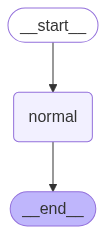

In [517]:
from IPython.display import display , Image
display(Image(app.get_graph().draw_mermaid_png()))

In [518]:
app.invoke({"human_feedback" : "Hey there"} , config=thread_config)

hello
[HumanMessage(content='Hey there', additional_kwargs={}, response_metadata={}, id='0a6a2c42-f81e-40ea-89e6-bbd17921fcdf')]
getlost


{'human_feedback': [HumanMessage(content='Hey there', additional_kwargs={}, response_metadata={}, id='0a6a2c42-f81e-40ea-89e6-bbd17921fcdf')],
 '__interrupt__': [Interrupt(value={'Add detail to your query Hey there'}, resumable=True, ns=['normal:4596d8fc-e40a-55e9-4b85-632c8a88dbf1', 'tools:797064dc-9056-666a-0c81-a9ceb4a57456'])]}

In [519]:
app.invoke(Command(resume="Tari masi ne ") , config=thread_config)

hello
[HumanMessage(content='Hey there', additional_kwargs={}, response_metadata={}, id='0a6a2c42-f81e-40ea-89e6-bbd17921fcdf')]
getlost
Tari masi ne 
getlost * 2
<class 'str'>
[DEKH LE] [HumanMessage(content="[HumanMessage(content='Hey there', additional_kwargs={}, response_metadata={}, id='0a6a2c42-f81e-40ea-89e6-bbd17921fcdf')]", additional_kwargs={}, response_metadata={}, id='4c943ea0-634f-4d07-b539-d2e6563fb76c'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'humman_feedback', 'arguments': '{"query": "Hey there"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, name='take user feedback', id='run--c712f2e1-463a-4c1e-a0ab-dab8dc8ffe05-0', tool_calls=[{'name': 'humman_feedback', 'args': {'query': 'Hey there'}, 'id': '99656f51-0623-43cb-9e2e-b601bde0b321', 'type': 'tool_call'}], usage_metadata={'input_tokens': 65, 'output_tokens': 7, 'total_tokens

{'human_feedback': [HumanMessage(content='Hey there', additional_kwargs={}, response_metadata={}, id='0a6a2c42-f81e-40ea-89e6-bbd17921fcdf'),
  HumanMessage(content='[HumanMessage(content="[HumanMessage(content=\'Hey there\', additional_kwargs={}, response_metadata={}, id=\'0a6a2c42-f81e-40ea-89e6-bbd17921fcdf\')]", additional_kwargs={}, response_metadata={}, id=\'4c943ea0-634f-4d07-b539-d2e6563fb76c\'), AIMessage(content=\'\', additional_kwargs={\'function_call\': {\'name\': \'humman_feedback\', \'arguments\': \'{"query": "Hey there"}\'}}, response_metadata={\'prompt_feedback\': {\'block_reason\': 0, \'safety_ratings\': []}, \'finish_reason\': \'STOP\', \'model_name\': \'gemini-2.0-flash\', \'safety_ratings\': []}, name=\'take user feedback\', id=\'run--c712f2e1-463a-4c1e-a0ab-dab8dc8ffe05-0\', tool_calls=[{\'name\': \'humman_feedback\', \'args\': {\'query\': \'Hey there\'}, \'id\': \'99656f51-0623-43cb-9e2e-b601bde0b321\', \'type\': \'tool_call\'}], usage_metadata={\'input_tokens\': 